In [1]:
include("MiniCollectiveSpins.jl")
include("Functions_time_evol_boxes.jl")
using PyPlot
using Statistics
using JLD2
using OrdinaryDiffEq

### Define the system

In [12]:
# Nbr of particles
N = 10
r = 100
d0_lb = 5e-10 # Minimum distance between the atoms (lower boundary) in m
λ = 421e-9
γ = 32.7e6 # In Hz
# sat = [0:1e-2:0.04;]
sat = [0:1:10;]
# sat = [5]
Ω_RO = γ.*sqrt.(sat/2)
# n0 = 5e3
n0 = 1e2

# Quantization axis along z
e = [0, 0, 1.]

# Normalisation
d0_lb = d0_lb / λ
Ω_RO = Ω_RO / γ
γ = 1.

t_end = 1e2

window_t, window_var = 2, 4
threshold_box = 1e-5; # Time over which the boxes are computed

# Plots of the time evolution

0.0%┣                                               ┫ 0/11 [00:00<00:00, -0s/it]
9.1%┣████                                       ┫ 1/11 [00:00<Inf:Inf, InfGs/it]
18.2%┣████████▌                                      ┫ 2/11 [00:02<00:14, 2s/it]
27.3%┣████████████▉                                  ┫ 3/11 [00:03<00:14, 2s/it]
36.4%┣█████████████████                              ┫ 4/11 [00:05<00:12, 2s/it]
45.5%┣█████████████████████▍                         ┫ 5/11 [00:06<00:09, 1s/it]
54.5%┣█████████████████████████▋                     ┫ 6/11 [00:06<00:06, 1s/it]
63.6%┣██████████████████████████████                 ┫ 7/11 [00:07<00:05, 1s/it]
72.7%┣██████████████████████████████████▏            ┫ 8/11 [00:08<00:03, 1s/it]
81.8%┣██████████████████████████████████████▌        ┫ 9/11 [00:09<00:02, 1s/it]
90.9%┣█████████████████████████████████████████▉    ┫ 10/11 [00:09<00:01, 1it/s]
100.0%┣█████████████████████████████████████████████┫ 11/11 [00:09<00:00, 1it/s]
100.0%┣█████████████████████

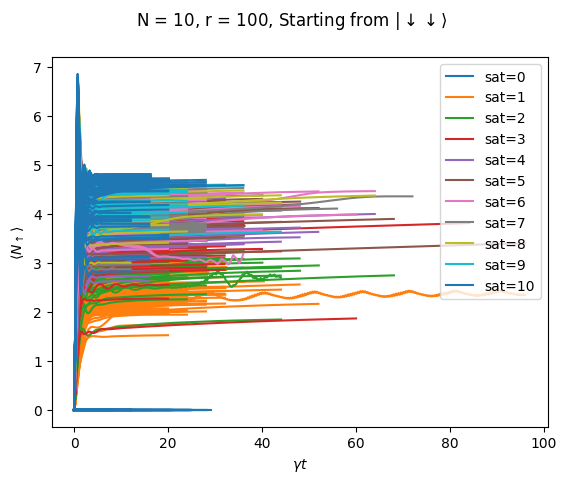

In [13]:
close("all")
fig, ax = subplots()
list_t_N, popup_t_N, nbr_error_t_N, sol_t_N = [], [], [], []

for (i, s) in ProgressBar(enumerate(sat))
    line = []
    @load "solutions/sol_N_$(N)_r_$(r)_sat_$(s)_n0_$n0.jld2" sol_tasks
    # @load "solutions/sol_N_$(N)_r_$(r)_sat_$(s).jld2" sol_tasks
    list_t, popup_t, nbr_error, sol_t =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
    push!(list_t_N, list_t), push!(popup_t_N, popup_t), push!(nbr_error_t_N, nbr_error), push!(sol_t_N, sol_t)
    for j in 1:length(popup_t)
        if j ∉ nbr_error
            if line == []
                line, = ax.plot(list_t[j], popup_t[j], label="sat=$(s)") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t[j], popup_t[j], color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  N_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N, r = $r, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

0.0%┣                                               ┫ 0/11 [00:00<00:00, -0s/it]
100.0%┣███████████████████████████████████████████┫ 11/11 [00:00<00:00, 204it/s]
100.0%┣███████████████████████████████████████████┫ 11/11 [00:00<00:00, 201it/s]


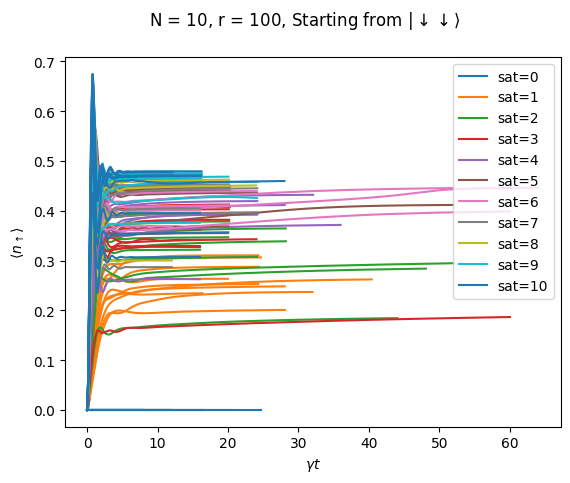

In [14]:
close("all")
fig, ax = subplots()

for (i, s) in ProgressBar(enumerate(sat))
    line = []
    for j in 1:10#length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if line == []
                line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, label="sat=$(s)") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N, r = $r, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

# Mean of the SS

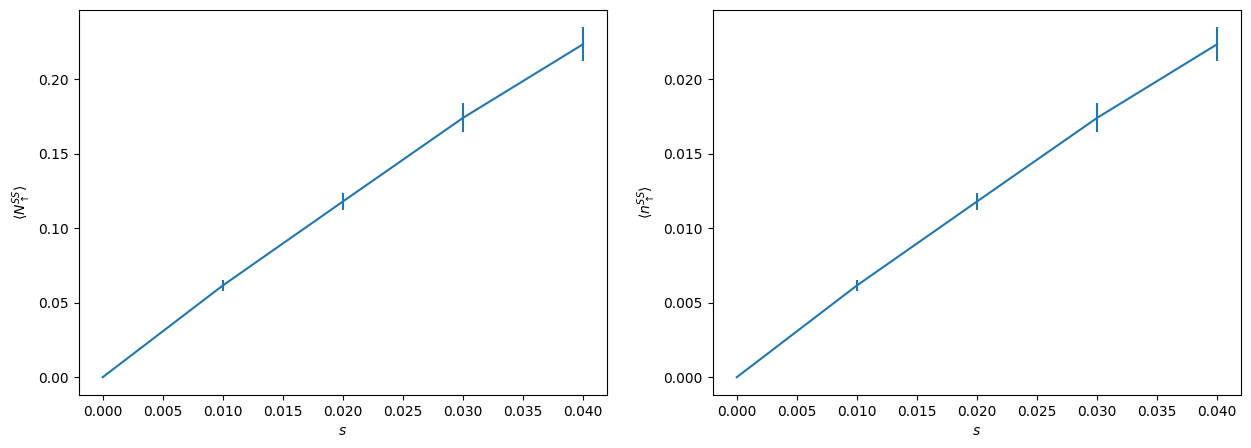

In [19]:
# For sat = 0, only throws errors as density to close from 0 --> remove the errors 
if 0 ∈ sat
    idx = findall(sat .== 0)[1]
    for i in 1:length(nbr_error_t_N[idx])
        if maximum(abs.(popup_t_N[idx][nbr_error_t_N[idx][i]])) < 10
            nbr_error_t_N[idx][i] = 0 # Physical solution
        end
    end
end

mean_SS = mean.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i]) if j ∉ nbr_error_t_N[i]] for i = 1:length(popup_t_N)])
std_SS = std.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i]) if j∉nbr_error_t_N[i]] for i = 1:length(popup_t_N)])

fig, axes = subplots(1, 2, figsize = (15, 5))
axes[1].errorbar(sat, mean_SS, yerr=std_SS ./ sqrt.([length(popup_t_N[i])-length(nbr_error_t_N[i]) for i = 1:length(sat)]))
axes[1].set_xlabel(L"s")
axes[1].set_ylabel(L"$\langle  N_{\uparrow}^{SS} \rangle $")

axes[2].errorbar(sat, mean_SS./N, yerr=std_SS ./ (N .* sqrt.([length(popup_t_N[i])-length(nbr_error_t_N[i]) for i = 1:length(sat)])))
axes[2].set_xlabel(L"s")
axes[2].set_ylabel(L"$\langle  n_{\uparrow}^{SS} \rangle $")


pygui(false); gcf();
# pygui(true); show()

# Comparison with spontaneous emission

In [20]:
function deriv_indep_atoms(du, u, p, t)
    γ, Ω = p[1], p[2]
    du[1] = -2γ*u[1] + 1im*Ω*(u[2]-conj(u[2])) # u[1] = ρee, u[2] = ρeg
    du[2] = -γ*u[2] + 1im*Ω*(2*u[1]-1)
end

deriv_indep_atoms (generic function with 1 method)

# Fit the independant case to the SS interacting case

In [21]:
function fit_γ_SE(n_up_SS, Ω)
    return Ω*sqrt(1/n_up_SS - 2)
end

fit_γ_SE (generic function with 1 method)

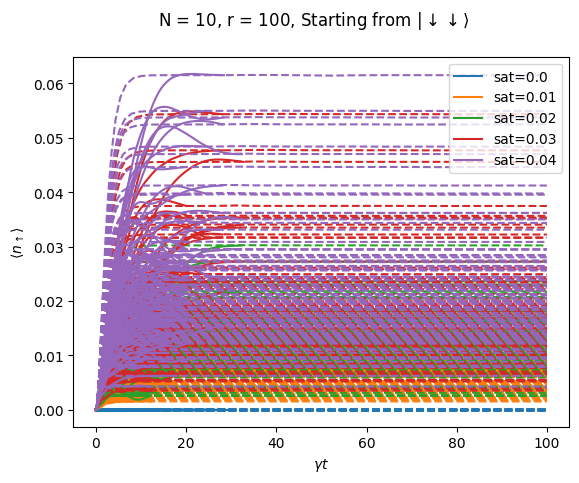

In [22]:
close("all")
fig, ax = subplots()

u0_indep = zeros(ComplexF64, 2)
decay_rate_interactions_eq_indep = zeros((length(sat), r))


for (i, s) in enumerate(sat)
    line = []
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if line == []
                line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] ./ N, label="sat=$(s)") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t_N[i][j], popup_t_N[i][j] ./ N, color=line.get_color()) # marker="o", markersize=1,
            end

            if popup_t_N[i][j][end] > 0
                γ_fit_SE = fit_γ_SE(popup_t_N[i][j][end]/N, Ω_RO[i])
                prob = ODEProblem(deriv_indep_atoms, u0_indep, (0, t_end), [γ_fit_SE, Ω_RO[i]])
                sol_indep = solve(prob)
                plot(sol_indep.t, real([sol[1] for sol in sol_indep.u]), linestyle="--", color=line.get_color())

                decay_rate_interactions_eq_indep[i, j] = γ_fit_SE
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N, r = $r, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

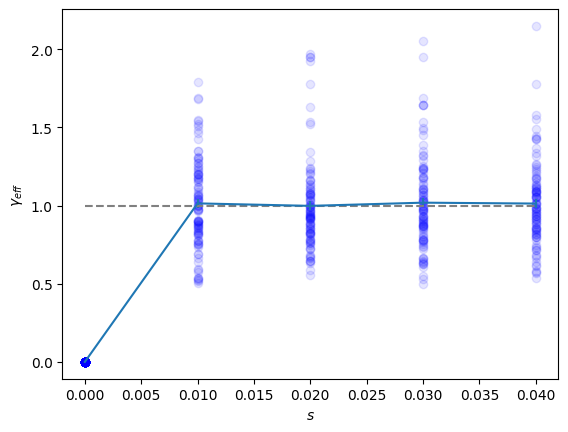

In [23]:
close("all")
fig = subplots()

errorbar(sat, [mean([decay_rate_interactions_eq_indep[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([decay_rate_interactions_eq_indep[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)])

for (i, s) in enumerate(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(s, decay_rate_interactions_eq_indep[i, j], color="blue", alpha=0.1)
        end
    end
end
 
xlabel(L"s")
ylabel(L"\gamma_{eff}")

hlines(1, sat[1], sat[end], linestyle="--", color="grey")
# ylim(0, 1.5)
# pygui(true); show()
pygui(false); 

### Weighted equivalent independant decay rate

In [24]:
decay_rate_interactions_eq_indep_weighted = zeros(ComplexF64, (length(sat), r))

for (i, s) in enumerate(sat)
    @load "op_list/op_list_$N.jdl2" op_list
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            sol_SS = sol_t_N[i][j][end]

            decay_rate_interactions_eq_indep_weighted[i, j] += 2*decay_rate_interactions_eq_indep[i, j]*sum(sol_SS[a] for a = 1:N)
            decay_rate_interactions_eq_indep_weighted[i, j] -= 2*Ω_RO[i]*sum([imag(sol_SS[a]) for a = N+1:2*N])

        end
    end
end
decay_rate_interactions_eq_indep_weighted

5×100 Matrix{ComplexF64}:
       0.0+0.0im                0.0+0.0im          …        0.0+0.0im
 0.0628311+3.1923e-20im   0.0564913+2.81897e-18im     0.0919158+8.94795e-19im
  0.152713+2.82848e-19im   0.128355-8.92142e-20im      0.228031-3.77796e-19im
  0.312398-7.44987e-18im   0.176463+8.40313e-19im      0.265061-3.37009e-19im
   0.25971+3.30728e-18im   0.347766+3.63509e-18im      0.424414+4.84143e-19im

In [25]:
decay_rate_interactions_eq_indep_weighted = real.(decay_rate_interactions_eq_indep_weighted)

5×100 Matrix{Float64}:
 0.0        0.0        0.0        …  0.0       0.0        0.0
 0.0628311  0.0564913  0.0875037     0.106902  0.0948199  0.0919158
 0.152713   0.128355   0.22191       0.176994  0.210334   0.228031
 0.312398   0.176463   0.482099      0.194615  0.307349   0.265061
 0.25971    0.347766   0.400415      0.289118  0.307964   0.424414

### Weighted corresponding independant decay rate

In [26]:
decay_rate_independant_eq_indep_weighted = zeros(ComplexF64, (length(sat), r))

for (i, s) in enumerate(sat)
    @load "op_list/op_list_$N.jdl2" op_list
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            sol_SS = sol_t_N[i][j][end]

            decay_rate_independant_eq_indep_weighted[i, j] += 2*γ*sum(sol_SS[a] for a = 1:N)
            decay_rate_independant_eq_indep_weighted[i, j] -= 2*Ω_RO[i]*sum([imag(sol_SS[a]) for a = N+1:2*N])

        end
    end
end
decay_rate_independant_eq_indep_weighted

5×100 Matrix{ComplexF64}:
 -4.86026e-15+7.13453e-30im  …  1.05036e-15+3.55697e-31im
    0.0388298+1.90128e-20im       0.0853152+8.30622e-19im
     0.129626+2.44513e-19im        0.325534-5.17341e-19im
     0.378532-8.88558e-18im        0.266751-3.38954e-19im
     0.204567+2.74229e-18im        0.698737+7.2559e-19im

In [27]:
decay_rate_independant_eq_indep_weighted = real.(decay_rate_independant_eq_indep_weighted)

5×100 Matrix{Float64}:
 -4.86026e-15  -6.40036e-7  -2.35102e-20  …  -1.80531e-8  1.05036e-15
  0.0388298     0.0324126    0.10501          0.106085    0.0853152
  0.129626      0.097937     0.263358         0.232863    0.325534
  0.378532      0.110738     0.927011         0.356367    0.266751
  0.204567      0.356804     0.5061           0.257848    0.698737

### Plots

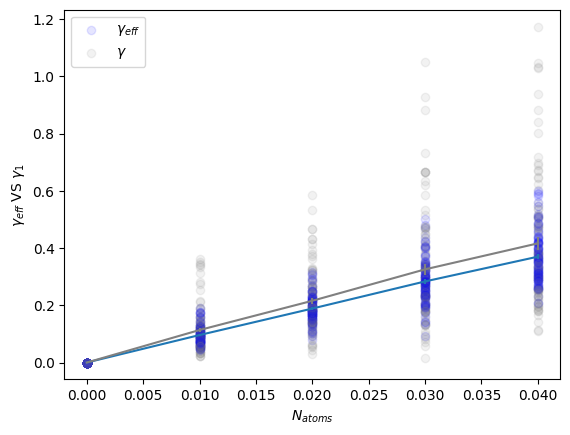

In [28]:
close("all")
fig = subplots()

errorbar(sat, [mean([decay_rate_interactions_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:1:length(sat)], yerr=[std([decay_rate_interactions_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)])
errorbar(sat, [mean([decay_rate_independant_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:1:length(sat)], yerr=[std([decay_rate_independant_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)], color="grey")

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], decay_rate_interactions_eq_indep_weighted[i, j], color="blue", alpha=0.1)
            scatter(sat[i], decay_rate_independant_eq_indep_weighted[i, j], color="grey", alpha=0.1)
        end
    end
end

legend([L"\gamma_{eff}", L"γ"])
xlabel(L"N_{atoms}")
ylabel(L"$\gamma_{eff}$ VS $\gamma_1$")

# hlines(1, N_list[1], N_list[end], linestyle="--", color="grey")
# ylim(0, 1.5)
# pygui(true); show()
pygui(false);

# Compute a decay rate from the $\Gamma$ matrix

In [29]:
decay_rate_interactions_Gamma_matrix = zeros(ComplexF64, (length(sat), r))

for (i, s) in enumerate(sat)
    @load "op_list/op_list_$N.jdl2" op_list

    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            @load "r0/r0_N_$(N)_r_$j.jdl2" r0 L
            system = SpinCollection(r0, e, gammas=1.)
            Γ_CS = GammaMatrix(system)
            
            sol_SS = sol_t_N[i][j][end]

            for a = 1:N
                for b = 1:N
                    if a == b
                        decay_rate_interactions_Gamma_matrix[i, j] += Γ_CS[a, a]*sol_SS[a]
                    end
                    if b > a
                        # corr = [21*10^(floor(Int, log10(a))+1)+a, 12*10^(floor(Int, log10(b))+1)+b]
                        corr = [22*10^(floor(Int, log10(a))+1)+a, 22*10^(floor(Int, log10(b))+1)+b]
                        try
                            decay_rate_interactions_Gamma_matrix[i, j] += 2*Γ_CS[a, b]*sol_SS[findall(x->x==corr || x==reverse(corr), op_list)[1]]
                        catch
                            println("Error @ $N, r=$j, a=$a, b=$b, corr=$corr")
                        end
                    end
                end
            end
        end
    end
end
decay_rate_interactions_Gamma_matrix

5×100 Matrix{ComplexF64}:
 -2.58234e-15+3.24577e-30im  …  1.33272e-15+2.17753e-31im
    0.0177557+8.35271e-21im       0.0432659+4.16445e-19im
    0.0752959+1.02956e-19im        0.182198-2.43269e-19im
     0.221895-3.74773e-18im        0.157764+1.46467e-19im
     0.141778+1.82487e-18im        0.492297+6.72206e-19im

In [30]:
decay_rate_interactions_Gamma_matrix = real.(decay_rate_interactions_Gamma_matrix)

5×100 Matrix{Float64}:
 -2.58234e-15  -3.16437e-7  -1.15895e-20  …  -1.01706e-8  1.33272e-15
  0.0177557     0.0175482    0.0663013        0.0619191   0.0432659
  0.0752959     0.0663592    0.143565         0.122041    0.182198
  0.221895      0.0681428    0.56448          0.202017    0.157764
  0.141778      0.220971     0.30751          0.147528    0.492297

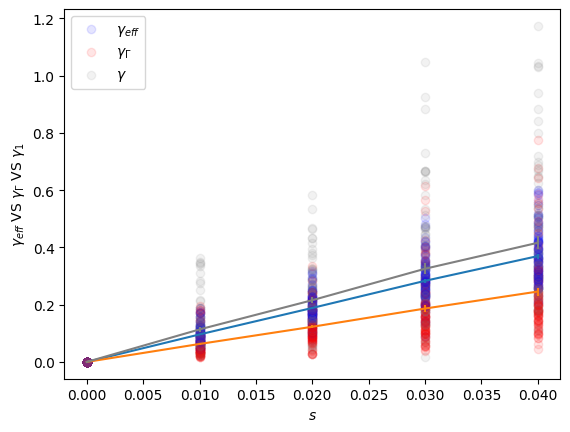

In [31]:
close("all")
fig = subplots()

errorbar(sat, [mean([decay_rate_interactions_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([decay_rate_interactions_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)])
errorbar(sat, [mean([decay_rate_interactions_Gamma_matrix[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([decay_rate_interactions_Gamma_matrix[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)])
errorbar(sat, [mean([decay_rate_independant_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([decay_rate_independant_eq_indep_weighted[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r) for i in 1:length(sat)], color="grey")

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], decay_rate_interactions_eq_indep_weighted[i, j], color="blue", alpha=0.1)
            scatter(sat[i], decay_rate_interactions_Gamma_matrix[i, j], color="red", alpha=0.1)
            scatter(sat[i], decay_rate_independant_eq_indep_weighted[i, j], color="grey", alpha=0.1)
        end
    end
end

legend([L"\gamma_{eff}", L"\gamma_\Gamma", L"γ"])

xlabel(L"s")
ylabel(L"$\gamma_{eff}$ VS $\gamma_\Gamma$ VS $\gamma_1$")
# pygui(true); show()
pygui(false);

# Plot the decay of SR without SE

In [32]:
function decay_atoms_indep(sat, N, γ)
    return N*γ/2 .* 1 ./ (1 .+ 1 ./sat)
end

decay_atoms_indep (generic function with 1 method)

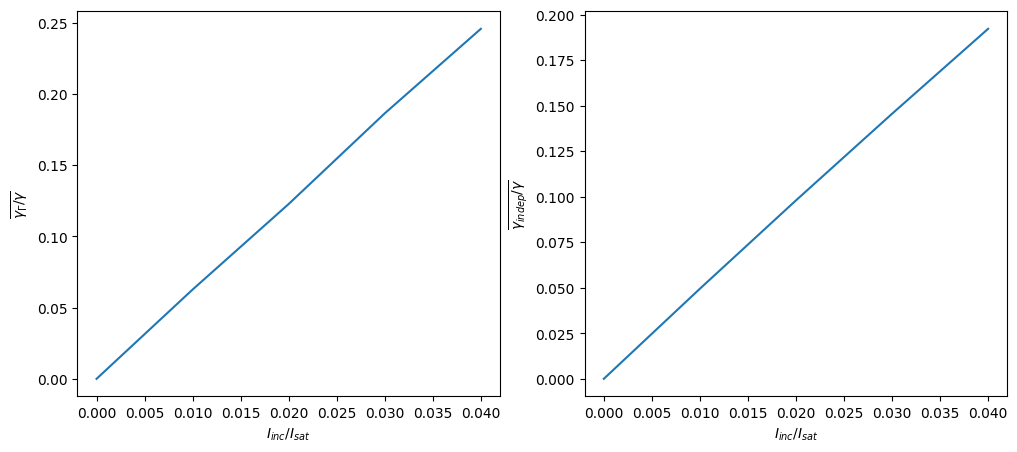

In [33]:
close("all")
fig, axs = subplots(1, 2, figsize=(12, 5))

axs[1].plot(sat, [mean([decay_rate_interactions_Gamma_matrix[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)])
axs[1].set_xlabel(L"$I_{inc}/I_{sat}$")
axs[1].set_ylabel(L"\overline{\gamma_\Gamma/\gamma}")

axs[2].plot(sat, decay_atoms_indep(sat, N, γ))
axs[2].set_xlabel(L"$I_{inc}/I_{sat}$")
axs[2].set_ylabel(L"\overline{\gamma_{indep}/\gamma}")

# pygui(true); show();
pygui(false);

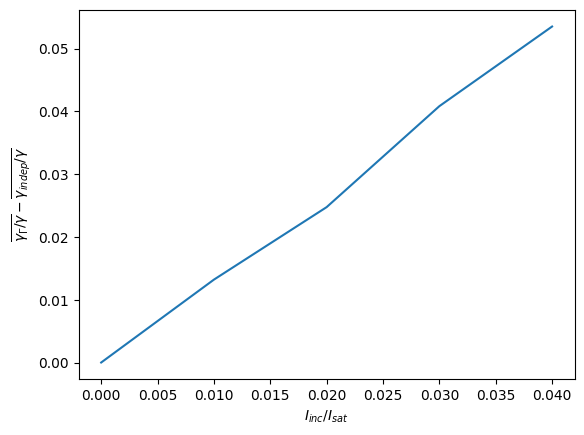

In [ ]:
close("all")
fig, axs = subplots()

plot(sat, [mean([decay_rate_interactions_Gamma_matrix[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)]-decay_atoms_indep(sat, N, γ))
xlabel(L"$I_{inc}/I_{sat}$")
ylabel(L"\overline{\gamma_\Gamma/\gamma}-\overline{\gamma_{indep}/\gamma}")
 
# pygui(true); show();
pygui(false);